# Analytic Guazzotto–Freidberg equilibrium

Solov'ev equilibria take $p'$ and $FF'$ constant. That makes them exact, but it
also leaves the pressure gradient and the toroidal current density with a jump
at the plasma edge. Guazzotto and Freidberg (J. Plasma Phys. **87**, 905870303,
2021, Part 1) take the free functions quadratic in the flux instead:

$$p = p_0\psi^2,\qquad F^2 = R_0^2B_0^2\left(1 + 2\frac{\delta B}{B_0}\psi^2\right),$$

so $p$, $p'$ and $J_\phi$ all vanish on the surface ($\psi = 0$). The
Grad–Shafranov equation becomes linear and homogeneous, so it is an
**eigenvalue problem**. In $R = R_0\sqrt{1+\varepsilon^2+2\varepsilon x}$ and
$Z = ay$, the eigenvalue $\alpha$ fixes the axis flux $\Psi_0$. The solution
is a sum of 7 separable terms (12 for an up-down asymmetric single null),
with the separation constants of the paper's Eq. (3.3) and radial functions
given by rapidly converging power series (Appendix A). The shape is imposed by
the flux, slope and curvature at the midplane and top points, or at an X-point.

Only four inputs fix the flux surfaces: $\varepsilon$, $\kappa$, $\delta$ (or
$\kappa_X$, $\delta_X$) and $\nu \approx \beta_p$. The global quantities then
follow once the axis beta $\beta_0$ is fixed, or equivalently the safety
factor on axis $q_0$.

Part 2 (J. Plasma Phys. **87**, 905870305, 2021) keeps the same machinery and
adds an edge current pedestal, a pressure pedestal with an edge bootstrap
surface current, and toroidal flow; it is the last part of this notebook.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from vaft.process.equilibrium import (
    evaluate_guazzotto_freidberg, guazzotto_freidberg_parameters,
    guazzotto_freidberg_to_equilibrium, solve_guazzotto_freidberg, solovev_example,
)
from vaft.plot.analytic import plot_solovev_equilibrium

# Table 4 of the paper (q0 = 1): inputs and the published (beta_T, beta_P, l_i, q95, q*, alpha).
table = {
    "circle":               (("limited", 0.33, 1.0, 0.0, None, None, 1.0),  (0.014, 1, 1.04, 3.21, 2.88, 2.38)),
    "ellipse":              (("limited", 0.25, 2.0, 0.0, None, None, 1.0),  (0.018, 1, 0.85, 3.32, 3.04, 1.88)),
    "elongated D (d=0.6)*": (("limited", 0.33, 1.8, 0.6, None, None, 0.3),  (0.0084, 0.27, 0.85, 3.84, 2.90, 1.96)),
    "high-triangularity D": (("limited", 0.4, 2.0, 0.75, None, None, 1.0),  (0.024, 1, 0.91, 6.82, 4.71, 2.05)),
    "inverse D":            (("limited", 0.33, 1.9, -0.6, None, None, 0.5), (0.014, 0.49, 0.97, 3.12, 3.08, 1.91)),
    "double null":          (("double_null", 0.33, None, None, 2.0, 0.5, 0.4),  (0.011, 0.38, 0.86, 3.74, 2.65, 1.96)),
    "double null, ST":      (("double_null", 0.75, None, None, 2.4, 0.8, 1.04), (0.041, 1.05, 0.97, 18.2, 5.57, 1.90)),
    "single null":          (("lower_single_null", 0.33, 1.6, 0.4, 2.0, 0.5, 1.0), (0.020, 1, 0.93, 4.45, 3.05, 2.04)),
    "single null, high bp": (("lower_single_null", 0.25, 1.8, 0.6, 2.1, 0.8, 2.1), (0.018, 2.16, 1.00, 6.17, 3.71, 2.09)),
}
models = {}
print(f"{'case':22s} {'beta_T':>13s} {'beta_P':>11s} {'l_i':>11s} {'q95':>11s} {'q*':>11s} {'alpha':>11s}")
for name, ((topology, eps, kappa, delta, kx, dx, nu), published) in table.items():
    models[name] = solve_guazzotto_freidberg(topology, inverse_aspect_ratio=eps, nu=nu, elongation=kappa,
                                             triangularity=delta, x_point_elongation=kx, x_point_triangularity=dx)
    got = guazzotto_freidberg_parameters(models[name], q0=1.0)
    cells = [f"{got[k]:.3g}/{v:g}" for k, v in zip(("beta_t", "beta_p", "li", "q95", "q_star", "alpha"), published)]
    print(f"{name:22s} " + " ".join(f"{c:>11s}" for c in cells))
print("(computed/published)")


case                          beta_T      beta_P         l_i         q95          q*       alpha


circle                 0.0137/0.014         1/1   1.04/1.04   3.18/3.21   2.87/2.88   2.38/2.38


ellipse                0.0181/0.018         1/1  0.852/0.85   3.33/3.32   3.04/3.04   1.88/1.88


elongated D (d=0.6)*   0.00826/0.0084  0.274/0.27  0.847/0.85   3.83/3.84     2.9/2.9   1.96/1.96


high-triangularity D   0.0244/0.024         1/1  0.914/0.91   6.84/6.82   4.71/4.71   2.05/2.05


inverse D              0.0138/0.014  0.494/0.49  0.866/0.97   3.12/3.12   3.07/3.08   1.91/1.91


double null            0.0107/0.011  0.376/0.38  0.862/0.86   3.74/3.74   2.65/2.65   1.96/1.96


double null, ST        0.0412/0.041   1.05/1.05  0.974/0.97   18.2/18.2   5.56/5.57     1.9/1.9


single null            0.0202/0.02         1/1   0.93/0.93   4.44/4.45   3.04/3.05   2.04/2.04


single null, high bp   0.0177/0.018   2.16/2.16         1/1    6.2/6.17   3.71/3.71   2.09/2.09
(computed/published)


Every published value is reproduced to the table's printed precision, and
the eigenvalue to all printed digits, with two exceptions. Both are pinned in
`test/test_guazzotto_freidberg.py`:

1. **Elongated D.** Table 1 and Fig. 3 give $\delta = 0.4$, but the Table 4
   row is reproduced completely with $\delta = 0.6$, as done above.
   $\delta = 0.4$ gives $\alpha = 1.921$ and $q_{95} = 3.44$ instead.
2. **Inverse D, $l_i$.** Every other column matches. The paper prints 0.97
   where the solution gives 0.87; a direct $2\int B_p^2 dV/(\mu_0^2I^2R_0)$
   agrees with 0.87, so this is most likely a misprint.

Two readings of the paper are needed. The divertor $q_*$ uses
"$\kappa_{95}$", which the paper does not define. Taking it as the height of
the $\psi = 0.05$ surface over the full width $2a$ reproduces all four
published values. Eq. (5.4 h, i) prints the single-null X-point conditions at
$(-\delta_X, -\kappa_X)$; the X-point of Eq. (5.3 d), $(-x_X, -\kappa_X)$, is
the reading that reproduces the single-null rows.

## A VEST-like shape in all three topologies

The same machinery at VEST's aspect ratio ($R_0 = 0.4$ m, $a = 0.235$ m), with
$\nu = 0.5$ and $q_0 = 1$. The exported record is an ordinary
`EquilibriumData` in COCOS 11, so VAFT's own plotting and topology tools apply
to it. The red line is the plasma boundary, and the X-points found on the grid are marked.

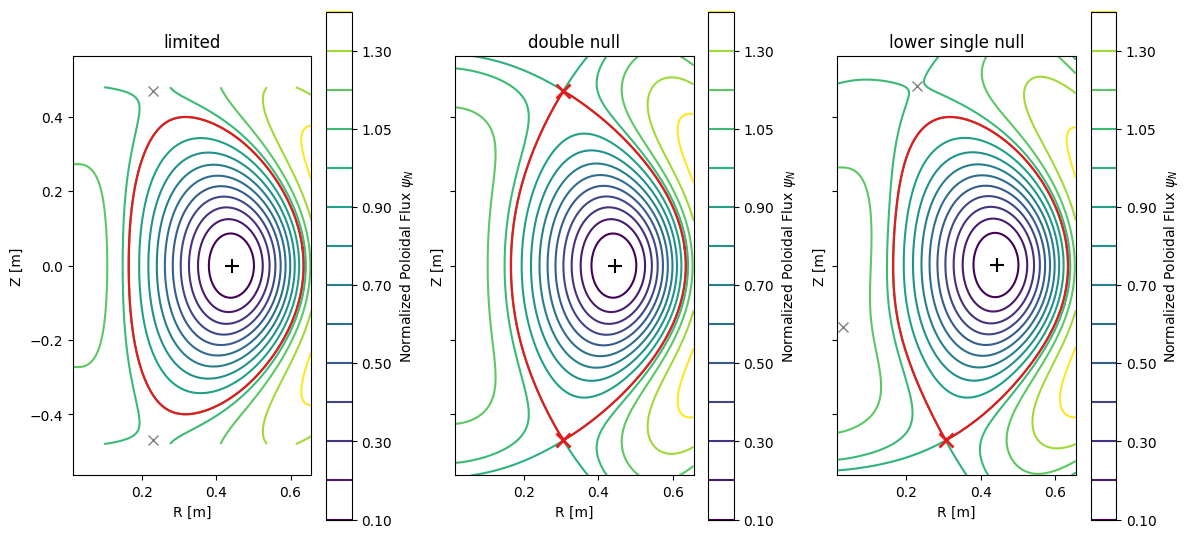

limited            alpha=1.8980  Ip= 42.73 kA  beta_p=0.442  l_i=0.848  q95=5.49
double_null        alpha=1.9044  Ip= 42.45 kA  beta_p=0.444  l_i=0.844  q95=5.69
lower_single_null  alpha=1.9010  Ip= 42.60 kA  beta_p=0.443  l_i=0.846  q95=5.58


In [ ]:
eps_v = 0.235 / 0.4
vest = {
    "limited": solve_guazzotto_freidberg("limited", inverse_aspect_ratio=eps_v, nu=0.5, elongation=1.7, triangularity=0.35),
    "double_null": solve_guazzotto_freidberg("double_null", inverse_aspect_ratio=eps_v, nu=0.5,
                                             x_point_elongation=2.0, x_point_triangularity=0.4),
    "lower_single_null": solve_guazzotto_freidberg("lower_single_null", inverse_aspect_ratio=eps_v, nu=0.5,
                                                   elongation=1.7, triangularity=0.35,
                                                   x_point_elongation=2.0, x_point_triangularity=0.4),
}
exported = {t: guazzotto_freidberg_to_equilibrium(m, major_radius=0.4, toroidal_field=0.1, resolution=161)
            for t, m in vest.items()}
fig, axes = plt.subplots(1, 3, figsize=(12, 5.6), sharey=True)
for ax, (topology, eq_t) in zip(axes, exported.items()):
    plot_solovev_equilibrium(eq_t, ax=ax, title=topology.replace("_", " "))
fig.tight_layout(); plt.show()
for topology, eq_t in exported.items():
    par = eq_t.metadata["parameters"]
    print(f"{topology:18s} alpha={vest[topology].alpha:.4f}  Ip={eq_t.ip/1e3:6.2f} kA  beta_p={par['beta_p']:.3f}  "
          f"l_i={par['li']:.3f}  q95={par['q95']:.2f}")


## What the modified source buys over Solov'ev

On the midplane, the Guazzotto–Freidberg pressure and current density go to
zero at the surface. A Solov'ev equilibrium of the same shape keeps a finite
pressure gradient and current density there.

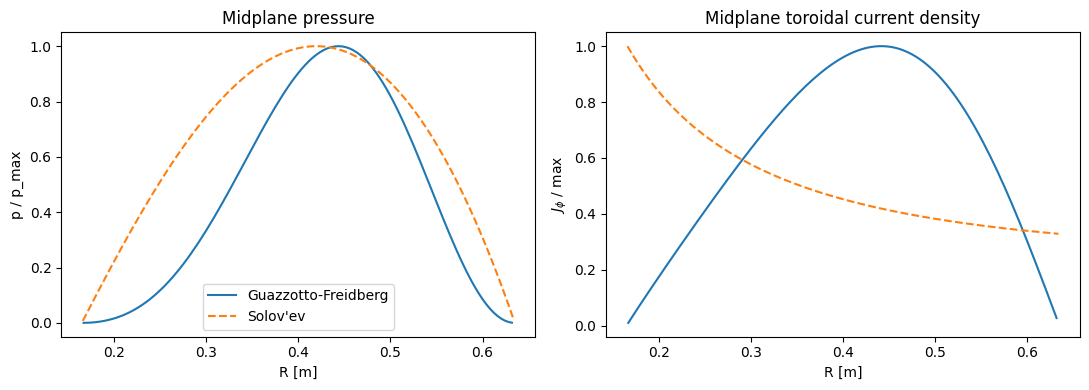

In [ ]:
gf = exported["limited"]
sv = solovev_example("limited", major_radius=0.4, aspect_ratio=1/eps_v, elongation=1.7, triangularity=0.35,
                     plasma_current=gf.ip, toroidal_field=0.1)

def midplane(eq):
    from scipy.constants import mu_0
    j_index = int(np.argmin(np.abs(eq.z - eq.magnetic_axis[1])))
    psi_n = (eq.psi[:, j_index] - eq.psi_axis) / (eq.psi_boundary - eq.psi_axis)
    order = np.argsort((eq.psi_1d - eq.psi_axis) / (eq.psi_boundary - eq.psi_axis))
    grid = ((eq.psi_1d - eq.psi_axis) / (eq.psi_boundary - eq.psi_axis))[order]
    inside = (psi_n >= 0) & (psi_n <= 1)
    p = np.where(inside, np.interp(psi_n, grid, eq.pressure[order]), np.nan)
    pp = np.interp(psi_n, grid, eq.pprime[order]); ff = np.interp(psi_n, grid, eq.ffprime[order])
    j = np.where(inside, -2 * np.pi * (eq.r * pp + ff / (mu_0 * eq.r)), np.nan)
    return eq.r, p / np.nanmax(p), j / np.nanmax(np.abs(j))

fig, (p_ax, j_ax) = plt.subplots(1, 2, figsize=(11, 4))
for eq_m, label, style in ((gf, "Guazzotto-Freidberg", "C0-"), (sv, "Solov'ev", "C1--")):
    r, p, j = midplane(eq_m)
    p_ax.plot(r, p, style, label=label); j_ax.plot(r, j, style, label=label)
p_ax.set(xlabel="R [m]", ylabel="p / p_max", title="Midplane pressure")
j_ax.set(xlabel="R [m]", ylabel=r"$J_\phi$ / max", title="Midplane toroidal current density")
p_ax.legend(); fig.tight_layout(); plt.show()


## $\nu$ as the poloidal-beta knob

$\nu = \mu_0p_0/(\mu_0p_0 + B_0\delta B/(1+\varepsilon^2))$ is the only source
input that changes the flux surfaces, and the paper shows $\nu \approx \beta_p$.
Above $\nu_{\max} = 1/\hat\varepsilon$ the inboard current reverses, and the
solver refuses that range.

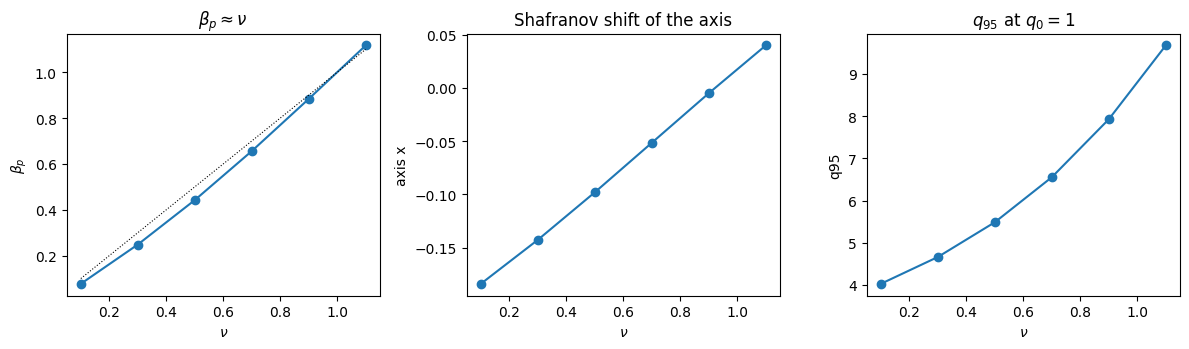

nu_max = 1/eps_hat = 1.145
nu = 1.3: nonphysical current reversal: nu=1.3 exceeds nu_max = 1/eps_hat = 1.145 (Eq. 2.10)


In [ ]:
nus = np.linspace(0.1, 1.1, 6)
rows = []
for nu in nus:
    m = solve_guazzotto_freidberg("limited", inverse_aspect_ratio=eps_v, nu=nu, elongation=1.7, triangularity=0.35)
    par = guazzotto_freidberg_parameters(m, q0=1.0)
    rows.append((nu, m.alpha, par["beta_p"], par["li"], par["q95"], m.magnetic_axis[0]))
rows = np.array(rows)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].plot(rows[:, 0], rows[:, 2], "o-"); axes[0].plot(rows[:, 0], rows[:, 0], "k:", lw=0.8)
axes[0].set(xlabel=r"$\nu$", ylabel=r"$\beta_p$", title=r"$\beta_p \approx \nu$")
axes[1].plot(rows[:, 0], rows[:, 5], "o-"); axes[1].set(xlabel=r"$\nu$", ylabel="axis x", title="Shafranov shift of the axis")
axes[2].plot(rows[:, 0], rows[:, 4], "o-"); axes[2].set(xlabel=r"$\nu$", ylabel="q95", title=r"$q_{95}$ at $q_0 = 1$")
fig.tight_layout(); plt.show()
eps_hat = 2 * eps_v / (1 + eps_v**2)
print(f"nu_max = 1/eps_hat = {1/eps_hat:.3f}")
try:
    solve_guazzotto_freidberg("limited", inverse_aspect_ratio=eps_v, nu=1.3, elongation=1.7, triangularity=0.35)
except ValueError as error:
    print("nu = 1.3:", error)


## Part 2: pedestals, surface currents and toroidal flow

Part 2 adds three edge effects, each reducing to Part 1 when switched off:

* **Current pedestal** $f_J = J_\phi(\mathrm{surf})/J_\phi(\mathrm{axis})$. Solov'ev-like
  terms linear in $\psi$ are added to $p$ and $F^2$ (Eq. 4.1). The equation
  becomes homogeneous in the shifted flux $\psi_J = \psi + f_J/(1-f_J)$, with
  the *inhomogeneous* boundary value $\psi_J(\mathrm{surf}) = f_J/(1-f_J)$.
  $\alpha$ is then the value at which $\psi_J(\mathrm{axis}) = 1/(1-f_J)$
  (Eq. 4.11). That value lies below Part 1's eigenvalue.
* **Pressure pedestal $f_P$ and edge bootstrap fraction $f_B$**. These are carried by a
  surface current sheet. They leave the interior flux unchanged. The exterior field
  ratio $\Delta_B = \hat B_0/B_0$ is iterated until the surface current carries
  $f_B$ of the total (Eqs. 3.9, 6.3), and $q_*$ and $l_i$ follow.
* **Toroidal flow** at axis Mach number $M_0$, adiabatic ($\gamma = 2$) or
  incompressible ($\gamma = \infty$). The source becomes $\alpha^2(1+\nu G(x))\psi_J$
  with $G$ a cubic or quadratic (Eq. 5.8), and the radial series gains two
  terms (Appendix B).

Table 2 of the paper applies these to Part 1's spherical double null
($\varepsilon = 0.75$, $\kappa_X = 2.4$, $\delta_X = 0.8$, $\nu = 1.04$, $q_0 = 1$).

In [ ]:
st = dict(inverse_aspect_ratio=0.75, nu=1.04, x_point_elongation=2.4, x_point_triangularity=0.8)
edge = dict(current_pedestal=0.25, pressure_pedestal=0.2, bootstrap_fraction=0.35)
table2 = {
    "reference (Part 1)": ({}, (1.05, 5.57)),
    "A: J pedestal": (dict(current_pedestal=0.25), (0.873, 4.00)),
    "B: p and J pedestals": (edge, (1.60, 2.62)),
    "C: B + adiabatic flow": (dict(edge, mach_number=0.4, adiabatic_index=2.0, allow_current_reversal=True), (1.59, 3.18)),
    "D: B + incompressible flow": (dict(edge, mach_number=0.4, adiabatic_index=np.inf, allow_current_reversal=True), (1.60, 2.89)),
}
part2 = {}
print(f"{'case':28s} {'alpha':>7s} {'beta_P':>12s} {'q*':>12s} {'Delta_B':>8s} {'I_hat/I':>8s} {'l_i':>6s}")
for name, (extra, (bp, qs)) in table2.items():
    part2[name] = solve_guazzotto_freidberg("double_null", **st, **extra)
    got = guazzotto_freidberg_parameters(part2[name], q0=1.0)
    print(f"{name:28s} {part2[name].alpha:7.4f} {got['beta_p']:6.3f}/{bp:<5g} {got['q_star']:6.3f}/{qs:<5g} "
          f"{got['surface_field_ratio']:8.4f} {got['total_current_ratio']:8.3f} {got['li']:6.3f}")
print("(computed/published); C and D:", part2["C: B + adiabatic flow"].status, "- see below")

$\beta_P$ is reproduced to 0.5 % and $q_*$ to 1.1 %. The Part 1 row this
starts from is itself 0.2 % low in $q_*$, a grid-integral error. The paper
leaves four points open, and each reading is pinned in
`test/test_guazzotto_freidberg_part2.py`:

1. **Cases C and D exceed $\nu_{\max}$.** Flow lowers the reversal limit to
   $\nu_{\max} = -1/G(-1) = 1.025$ (Eq. 5.7), but the paper keeps
   $\nu = 1.04$. The inboard edge current therefore reverses slightly. The solver refuses
   this by default; `allow_current_reversal=True` reproduces the table and marks the
   result `status="current_reversal"`.
2. **Surface-current jump.** Eq. (6.2) prints the toroidal-field term as
   $1-\Delta_B^2$. The field jump of Eqs. (3.6)–(3.9) makes it
   $(1-\Delta_B^2)R_0^2/R^2$, and that form is used here. The two differ by
   0.2 % in $q_*$.
3. **$\beta_T$ (Eq. 6.7)** prints the factor $\hat B_0^2/B_0^2$. Here $\beta_T$ is
   normalized to the exterior vacuum field, $2\mu_0\langle p\rangle/\hat B_0^2$.
4. **$l_i$ (Eq. 6.10)** weights the current with $1+\nu\hat\varepsilon x$. With flow the
   source is $1+\nu G$, which is what Ampère's law gives and what is used here. The
   two agree without flow.

Below, the flux surfaces of cases A and C are drawn over the Part 1 reference,
together with midplane $J_\phi$ and $p$ profiles, each normalized to its maximum.
These correspond to the paper's Figs. 1–3.

In [ ]:
def midplane_profiles(model, q0=1.0):
    eps = model.inverse_aspect_ratio
    x = np.linspace(-1, 1, 401)
    v = evaluate_guazzotto_freidberg(model, x, np.zeros_like(x))
    r = 1 + eps**2 + 2 * eps * x
    s1 = 2 * eps / (1 + eps**2) * model.nu
    m2, fj, fp = model.mach_number**2, model.current_pedestal, model.pressure_pedestal
    if model.mach_number == 0:
        nu_g, flow = s1 * x, np.ones_like(x)
    else:
        c = 2 * m2 * eps / (1 + m2 * eps**2)
        e = 1.0 if np.isinf(model.adiabatic_index) else model.adiabatic_index / (model.adiabatic_index - 1)
        g = (1 + 2 * eps / (1 + eps**2) * x) * (1 + c * x)**e - 1
        nu_g, flow = model.nu * g, (1 + c * x)**e
    j = (1 + nu_g) * v["psi_j"] / np.sqrt(r)                                   # Part 2, Eq. (6.1)
    p = flow * ((1 - fp) * (1 - fj) / (1 + fj) * v["psi_j"]**2 + (fp - fj**2) / (1 - fj**2))
    return np.sqrt(r), j / j.max(), p / p.max()

def surfaces(model, ax, colour, label):
    xs = np.linspace(-0.999, 0.999, 241); ys = np.linspace(-2.6, 2.6, 321)
    X, Y = np.meshgrid(xs, ys, indexing="ij")
    psi = evaluate_guazzotto_freidberg(model, X, Y)["psi"]
    eps = model.inverse_aspect_ratio
    R, Z = np.sqrt(1 + eps**2 + 2 * eps * X), eps * Y
    ax.contour(R, Z, psi, levels=[0.0, 0.2, 0.4, 0.6, 0.8], colors=colour, linewidths=0.9)
    ax.plot([], [], color=colour, label=label)

ref = part2["reference (Part 1)"]
fig, axes = plt.subplots(1, 4, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1, 1.4, 1, 1.4]})
for k, name in ((0, "A: J pedestal"), (2, "C: B + adiabatic flow")):
    surfaces(ref, axes[k], "0.3", "Part 1")
    surfaces(part2[name], axes[k], "tab:red", name.split(":")[0])
    axes[k].set_aspect("equal"); axes[k].set(xlabel="R/R0", ylabel="Z/R0", title=name); axes[k].legend(fontsize=8)
    for model, style, tag in ((ref, "--", "Part 1"), (part2[name], "-", name.split(":")[0])):
        R, j, p = midplane_profiles(model)
        axes[k + 1].plot(R, j, style, color="tab:blue", label=f"J_phi {tag}")
        axes[k + 1].plot(R, p, style, color="tab:orange", label=f"p {tag}")
    axes[k + 1].set(xlabel="R/R0", ylabel="normalized", title="midplane profiles"); axes[k + 1].legend(fontsize=8)
fig.tight_layout(); plt.show()

With a current pedestal, the edge $J_\phi$ and $p$ stay finite, and the current
profile flattens at fixed $q_0$. That raises the total current and lowers $q_*$.
Flow pushes the axis outward, and adiabatic flow ($\gamma = 2$) pushes it slightly
further than incompressible flow ($\gamma = \infty$), as the paper reports.

The same knobs at VEST's aspect ratio: scan $f_J$ with $f_P = 0.2$ and
$f_B = 0.2$, then scan the flow Mach number at $f_J = 0.2$.

In [ ]:
vest_shape = dict(inverse_aspect_ratio=eps_v, nu=0.5, elongation=1.7, triangularity=0.35)
f_js = [0.0, 0.1, 0.2, 0.3, 0.4]
scan_j = []
for f_j in f_js:
    m = solve_guazzotto_freidberg("limited", **vest_shape, current_pedestal=f_j, pressure_pedestal=0.2, bootstrap_fraction=0.2)
    par = guazzotto_freidberg_parameters(m, q0=1.0)
    scan_j.append((m.alpha, par["beta_p"], par["li"], par["q_star"]))
scan_j = np.array(scan_j)
machs = [0.0, 0.2, 0.4, 0.6]
scan_m = {}
for gamma in (2.0, np.inf):
    scan_m[gamma] = [solve_guazzotto_freidberg("limited", **vest_shape, current_pedestal=0.2, mach_number=m0,
                                               adiabatic_index=gamma if m0 > 0 else None).magnetic_axis[0]
                     for m0 in machs]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].plot(f_js, scan_j[:, 0], "o-"); axes[0].set(xlabel=r"$f_J$", ylabel=r"$\alpha$", title="eigenvalue drops with the pedestal")
axes[1].plot(f_js, scan_j[:, 3], "o-", label=r"$q_*$"); axes[1].plot(f_js, scan_j[:, 2], "s-", label=r"$l_i$")
axes[1].set(xlabel=r"$f_J$", title=r"$q_0 = 1$, $f_P = f_B = 0.2$"); axes[1].legend()
for gamma, label in ((2.0, r"$\gamma = 2$"), (np.inf, r"$\gamma = \infty$")):
    axes[2].plot(machs, scan_m[gamma], "o-", label=label)
axes[2].set(xlabel=r"$M_0$", ylabel="axis x", title="flow shifts the axis outward"); axes[2].legend()
fig.tight_layout(); plt.show()
print("nu_max with M0 = 0.6, gamma = 2:",
      f"{1 / (1 - (1 - 2*eps_v/(1+eps_v**2)) * (1 - 2*0.36*eps_v/(1+0.36*eps_v**2))**2):.3f}")